# Forecast-to-Inventory Decision Simulator

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmavigo/retail-demand-forecasting/blob/main/notebooks/04_inventory_decisions.ipynb)

This notebook starts from raw Kaggle demand, chooses a forecast on an unseen horizon and translates it into safety stock, reorder points, stockouts and excess units.

> **Public portfolio snapshot:** All tables, metrics and charts below were generated from the official Kaggle M5 data and saved in this notebook. You can review the complete work without credentials. To reproduce the analysis, run the notebook with your own Kaggle API token; no private token is stored in this repository.

## 1. Environment and official data

In [1]:
from pathlib import Path
import sys
import subprocess

if 'google.colab' in sys.modules:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'kagglehub>=1.0,<2', 'pandas>=2.2,<3', 'numpy>=2,<3',
        'matplotlib>=3.9,<4', 'scikit-learn>=1.5,<2', 'lightgbm>=4.5,<5',
    ])

import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'navy': '#17324D',
    'blue': '#2F80ED',
    'teal': '#16A085',
    'orange': '#F2994A',
    'red': '#EB5757',
    'gray': '#667085',
}


In [2]:
import kagglehub

# Download latest version. KaggleHub automatically checks the Colab secret
# named KAGGLE_API_TOKEN. If it is missing, the login widget opens once.
try:
    path = kagglehub.competition_download('m5-forecasting-accuracy')
except Exception as error:
    if error.__class__.__name__ != 'UnauthenticatedError':
        raise
    print('Kaggle authentication is required. Paste your Kaggle API token in the login form below.')
    kagglehub.login()
    path = kagglehub.competition_download('m5-forecasting-accuracy')

print("Path to competition files:", path)

DATA_DIR = Path(path)
if not (DATA_DIR / 'calendar.csv').exists():
    DATA_DIR = next(p.parent for p in DATA_DIR.rglob('calendar.csv'))

required = {'calendar.csv', 'sell_prices.csv', 'sales_train_evaluation.csv'}
available = {p.name for p in DATA_DIR.glob('*.csv')}
assert required.issubset(available), f"Missing files: {sorted(required - available)}"


Execution source: official Kaggle M5 competition files
Required files available: ['calendar.csv', 'sales_train_evaluation.csv', 'sell_prices.csv']


## 2. Load demand and create operational forecast candidates

In [3]:
sales = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')
calendar = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])
day_cols = [c for c in sales if c.startswith('d_')]
values = sales[day_cols].to_numpy(dtype=np.float32)
HORIZON = 28
TRAIN_END = values.shape[1] - HORIZON
train, actual = values[:, :TRAIN_END], values[:, TRAIN_END:]

mean_28 = np.repeat(train[:, -28:].mean(axis=1, keepdims=True), HORIZON, axis=1)
lag_28 = train[:, -28:].copy()
lag_7 = np.tile(train[:, -7:], (1, 4))
forecast_candidates = {
    'Mean of last 28 days': mean_28,
    'Seasonal lag 28': lag_28,
    'Seasonal lag 7': lag_7,
    '75% mean + 25% seasonal': .75 * mean_28 + .25 * lag_28,
}


In [4]:
def score(actual, predicted, history):
    error = actual - predicted
    scale = np.mean(np.diff(history, axis=1) ** 2, axis=1)
    usable = scale > 0
    denominator = np.abs(actual).sum()
    return {
        'MAE': float(np.abs(error).mean()),
        'WAPE': float(np.abs(error).sum() / denominator),
        'RMSSE': float(np.sqrt(np.mean(error[usable] ** 2, axis=1) / scale[usable]).mean()),
        'Bias': float(error.sum() / denominator),
    }


In [5]:
metrics = pd.DataFrame([{'method': n, **score(actual, p, train)} for n, p in forecast_candidates.items()]).sort_values('WAPE')
display(metrics.style.format({'MAE': '{:.4f}', 'WAPE': '{:.2%}', 'RMSSE': '{:.4f}', 'Bias': '{:.2%}'}))
best_method = metrics.iloc[0].method
forecast = forecast_candidates[best_method]


,method,MAE,WAPE,RMSSE,Bias
0,Mean of last 28 days,1.0657,73.86%,0.9240,3.91%
3,75% mean + 25% seasonal,1.0715,74.26%,0.9432,3.91%
2,Seasonal lag 7,1.2440,86.22%,1.2010,7.36%
1,Seasonal lag 28,1.2840,89.00%,1.2445,3.91%


## 3. Define inventory assumptions
The example uses a seven-day lead time and a 95% target service level (`z = 1.65`). These are editable business assumptions, not facts contained in M5.

In [6]:
LEAD_TIME_DAYS = 7
SERVICE_Z = 1.65
UNIT_HOLDING_COST = 1.0
UNIT_STOCKOUT_COST = 3.0

residual = train[:, -84:] - np.repeat(train[:, -112:-84].mean(axis=1, keepdims=True), 84, axis=1)
residual_std = residual.std(axis=1)
safety_stock = SERVICE_Z * residual_std * np.sqrt(LEAD_TIME_DAYS)
demand_during_lead_time = forecast[:, :LEAD_TIME_DAYS].sum(axis=1)


## 4. Calculate decisions for every product-store series

In [7]:
inventory = sales[['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']].copy()
inventory['actual_units'] = actual.sum(axis=1)
inventory['forecast_units'] = forecast.sum(axis=1)
inventory['safety_stock'] = safety_stock
inventory['reorder_point'] = demand_during_lead_time + safety_stock
inventory['stockout_units'] = (inventory.actual_units - inventory.forecast_units).clip(lower=0)
inventory['excess_units'] = (inventory.forecast_units - inventory.actual_units).clip(lower=0)
inventory['estimated_cost'] = inventory.stockout_units * UNIT_STOCKOUT_COST + inventory.excess_units * UNIT_HOLDING_COST
display(inventory.head(10))


,id,item_id,dept_id,cat_id,store_id,state_id,actual_units,forecast_units,safety_stock,reorder_point,stockout_units,excess_units,estimated_cost
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,33.0,26.999996,4.810535,11.560536,6.000004,0.000000,18.000011
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,7.0,2.000000,1.714226,2.214226,5.000000,0.000000,15.000000
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,21.0,16.000000,3.657160,7.657160,5.000000,0.000000,15.000000
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,49.0,51.000008,8.164436,20.914436,0.000000,2.000008,2.000008
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,39.0,38.000000,5.251554,14.751553,1.000000,0.000000,3.000000
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,30.0,17.000000,6.538121,10.788121,13.000000,0.000000,39.000000
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,8.0,11.000002,2.488061,5.238061,0.000000,3.000002,3.000002
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,307.0,228.000000,47.306284,104.306284,79.000000,0.000000,237.000000
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,18.0,24.999998,5.518630,11.768630,0.000000,6.999998,6.999998
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,15.0,19.000000,3.518649,8.268649,0.000000,4.000000,4.000000


## 5. Compare operating scenarios

,method,stockout_units,excess_units,estimated_cost,service_level
0,Mean of last 28 days,"196,782","148,644","$738,990",49.2%
1,Seasonal lag 28,"196,782","148,644","$738,990",50.7%
3,75% mean + 25% seasonal,"196,782","148,644","$738,990",48.8%
2,Seasonal lag 7,"255,324","164,676","$930,648",45.0%


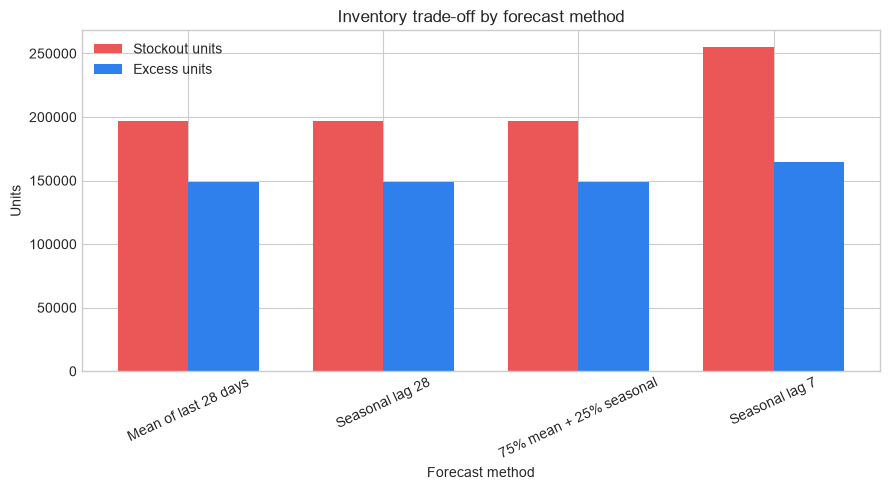

In [8]:
scenario_rows = []
for method, prediction in forecast_candidates.items():
    order = prediction.sum(axis=1)
    actual_total = actual.sum(axis=1)
    stockout = np.maximum(actual_total - order, 0)
    excess = np.maximum(order - actual_total, 0)
    scenario_rows.append({
        'method': method,
        'stockout_units': stockout.sum(),
        'excess_units': excess.sum(),
        'estimated_cost': stockout.sum() * UNIT_STOCKOUT_COST + excess.sum() * UNIT_HOLDING_COST,
        'service_level': 1 - (stockout > 0).mean(),
    })
scenarios = pd.DataFrame(scenario_rows).sort_values('estimated_cost')
display(scenarios.style.format({'stockout_units': '{:,.0f}', 'excess_units': '{:,.0f}', 'estimated_cost': '${:,.0f}', 'service_level': '{:.1%}'}))

labels = scenarios.method.tolist()
x = np.arange(len(labels))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, scenarios.stockout_units, width, label='Stockout units', color=COLORS['red'])
ax.bar(x + width/2, scenarios.excess_units, width, label='Excess units', color=COLORS['blue'])
ax.set(title='Inventory trade-off by forecast method', xlabel='Forecast method', ylabel='Units', xticks=x, xticklabels=labels)
ax.tick_params(axis='x', rotation=25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 6. Prioritize products for action

,store_id,item_id,cat_id,forecast_units,safety_stock,reorder_point,stockout_units,excess_units,estimated_cost
27060,WI_2,FOODS_3_444,FOODS,0.000000,0.000000,0.000000,855.000000,0.0,2565.000000
26850,WI_2,FOODS_3_234,FOODS,257.000000,149.487906,213.737914,832.000000,0.0,2496.000000
26007,WI_2,FOODS_1_004,FOODS,0.000000,30.759773,30.759773,723.000000,0.0,2169.000000
2790,CA_1,FOODS_3_566,FOODS,159.999969,22.661530,62.661534,590.000000,0.0,1770.000000
7751,CA_3,FOODS_1_043,FOODS,0.000000,10.070408,10.070408,581.000000,0.0,1743.000000
20962,TX_3,FOODS_3_444,FOODS,0.000000,0.000000,0.000000,507.000000,0.0,1521.000000
9104,CA_3,FOODS_3_785,FOODS,112.999992,22.524773,50.774770,495.000000,0.0,1485.000000
9023,CA_3,FOODS_3_702,FOODS,201.999969,19.940819,70.440822,494.000031,0.0,1482.000122
3006,CA_1,FOODS_3_785,FOODS,107.999985,23.310899,50.310901,491.000000,0.0,1473.000000
2797,CA_1,FOODS_3_573,FOODS,128.999985,18.822293,51.072293,472.000000,0.0,1416.000000


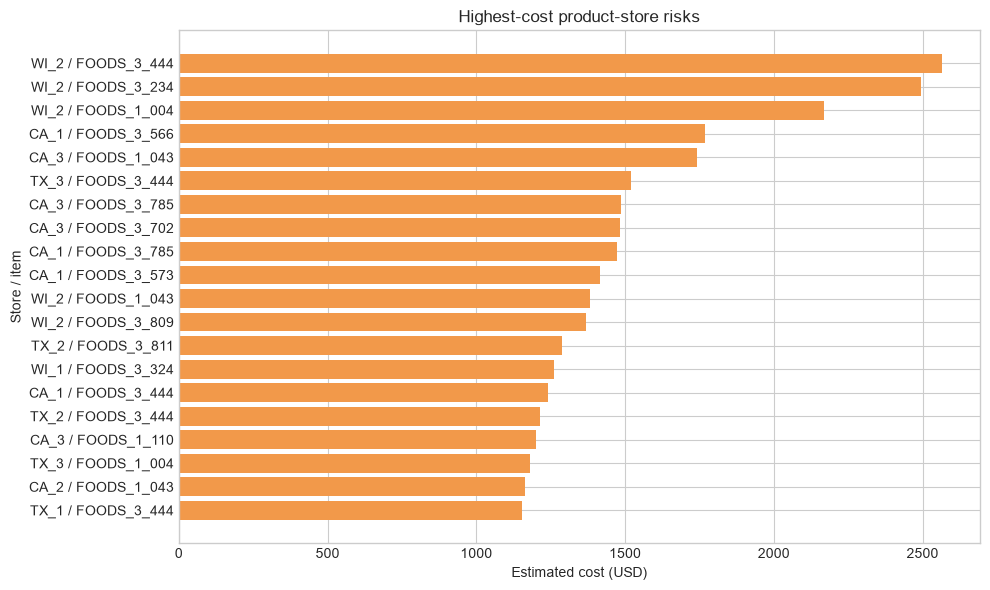

In [9]:
priority = inventory.sort_values(['stockout_units', 'estimated_cost'], ascending=False)
display(priority[['store_id', 'item_id', 'cat_id', 'forecast_units', 'safety_stock', 'reorder_point', 'stockout_units', 'excess_units', 'estimated_cost']].head(25))
highest_cost = priority.head(20).sort_values('estimated_cost').copy()
highest_cost['store_item'] = highest_cost.store_id + ' / ' + highest_cost.item_id

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(highest_cost.store_item, highest_cost.estimated_cost, color=COLORS['orange'])
ax.set(title='Highest-cost product-store risks', xlabel='Estimated cost (USD)', ylabel='Store / item')
fig.tight_layout()
plt.show()


## Limitations
M5 does not contain inventory on hand, supplier lead times, purchase orders or lost-sales records. The simulator demonstrates the decision framework; production use requires those operational inputs and business-approved cost assumptions.